# PCA and Visualization in Python

This notebook converts the original R code into Python using only Python libraries.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 2. Read the blue jays dataset

In [4]:
blue_jays = pd.read_csv("/kaggle/input/datasets/eimieimieimi86/pca-jays/blue_jays.csv")
blue_jays.head()

,bird_id,sex,bill_depth_mm,bill_width_mm,bill_length_mm,head_length_mm,body_mass_g,skull_size_mm
0,0000-00000,M,8.26,9.21,25.92,56.58,73.30,30.66
1,1142-05901,M,8.54,8.76,24.99,56.36,75.10,31.38
2,1142-05905,M,8.39,8.78,26.07,57.32,70.25,31.25
3,1142-05907,F,7.78,9.30,23.48,53.77,65.50,30.29
4,1142-05909,M,8.71,9.84,25.47,57.32,74.90,31.85


## 3. Scatter plot: head length vs body mass

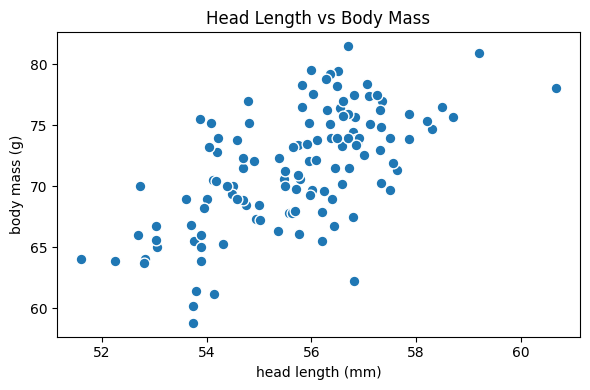

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(
    blue_jays["head_length_mm"],
    blue_jays["body_mass_g"],
    s=60,
    edgecolor="white"
)
plt.xlabel("head length (mm)")
plt.ylabel("body mass (g)")
plt.title("Head Length vs Body Mass")
plt.tight_layout()
plt.show()

## 4. Scatter plot by gender

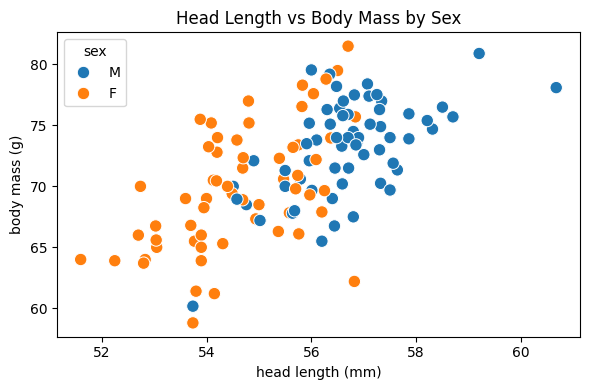

In [7]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=blue_jays,
    x="head_length_mm",
    y="body_mass_g",
    hue="sex",
    s=80
)
plt.xlabel("head length (mm)")
plt.ylabel("body mass (g)")
plt.title("Head Length vs Body Mass by Sex")
plt.tight_layout()
plt.show()

## 5. Scatter plot by gender with point size based on skull size

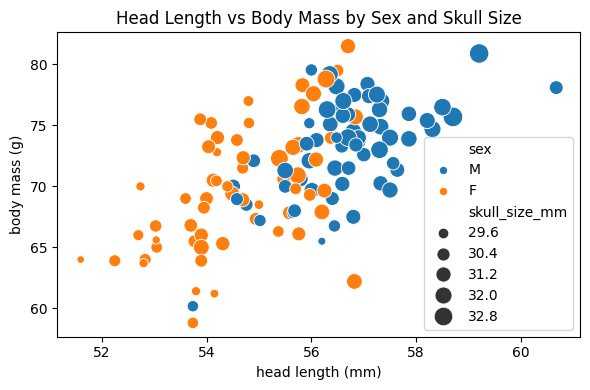

In [8]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=blue_jays,
    x="head_length_mm",
    y="body_mass_g",
    hue="sex",
    size="skull_size_mm",
    sizes=(30, 200)
)
plt.xlabel("head length (mm)")
plt.ylabel("body mass (g)")
plt.title("Head Length vs Body Mass by Sex and Skull Size")
plt.tight_layout()
plt.show()

## 6. Scatter plot matrix

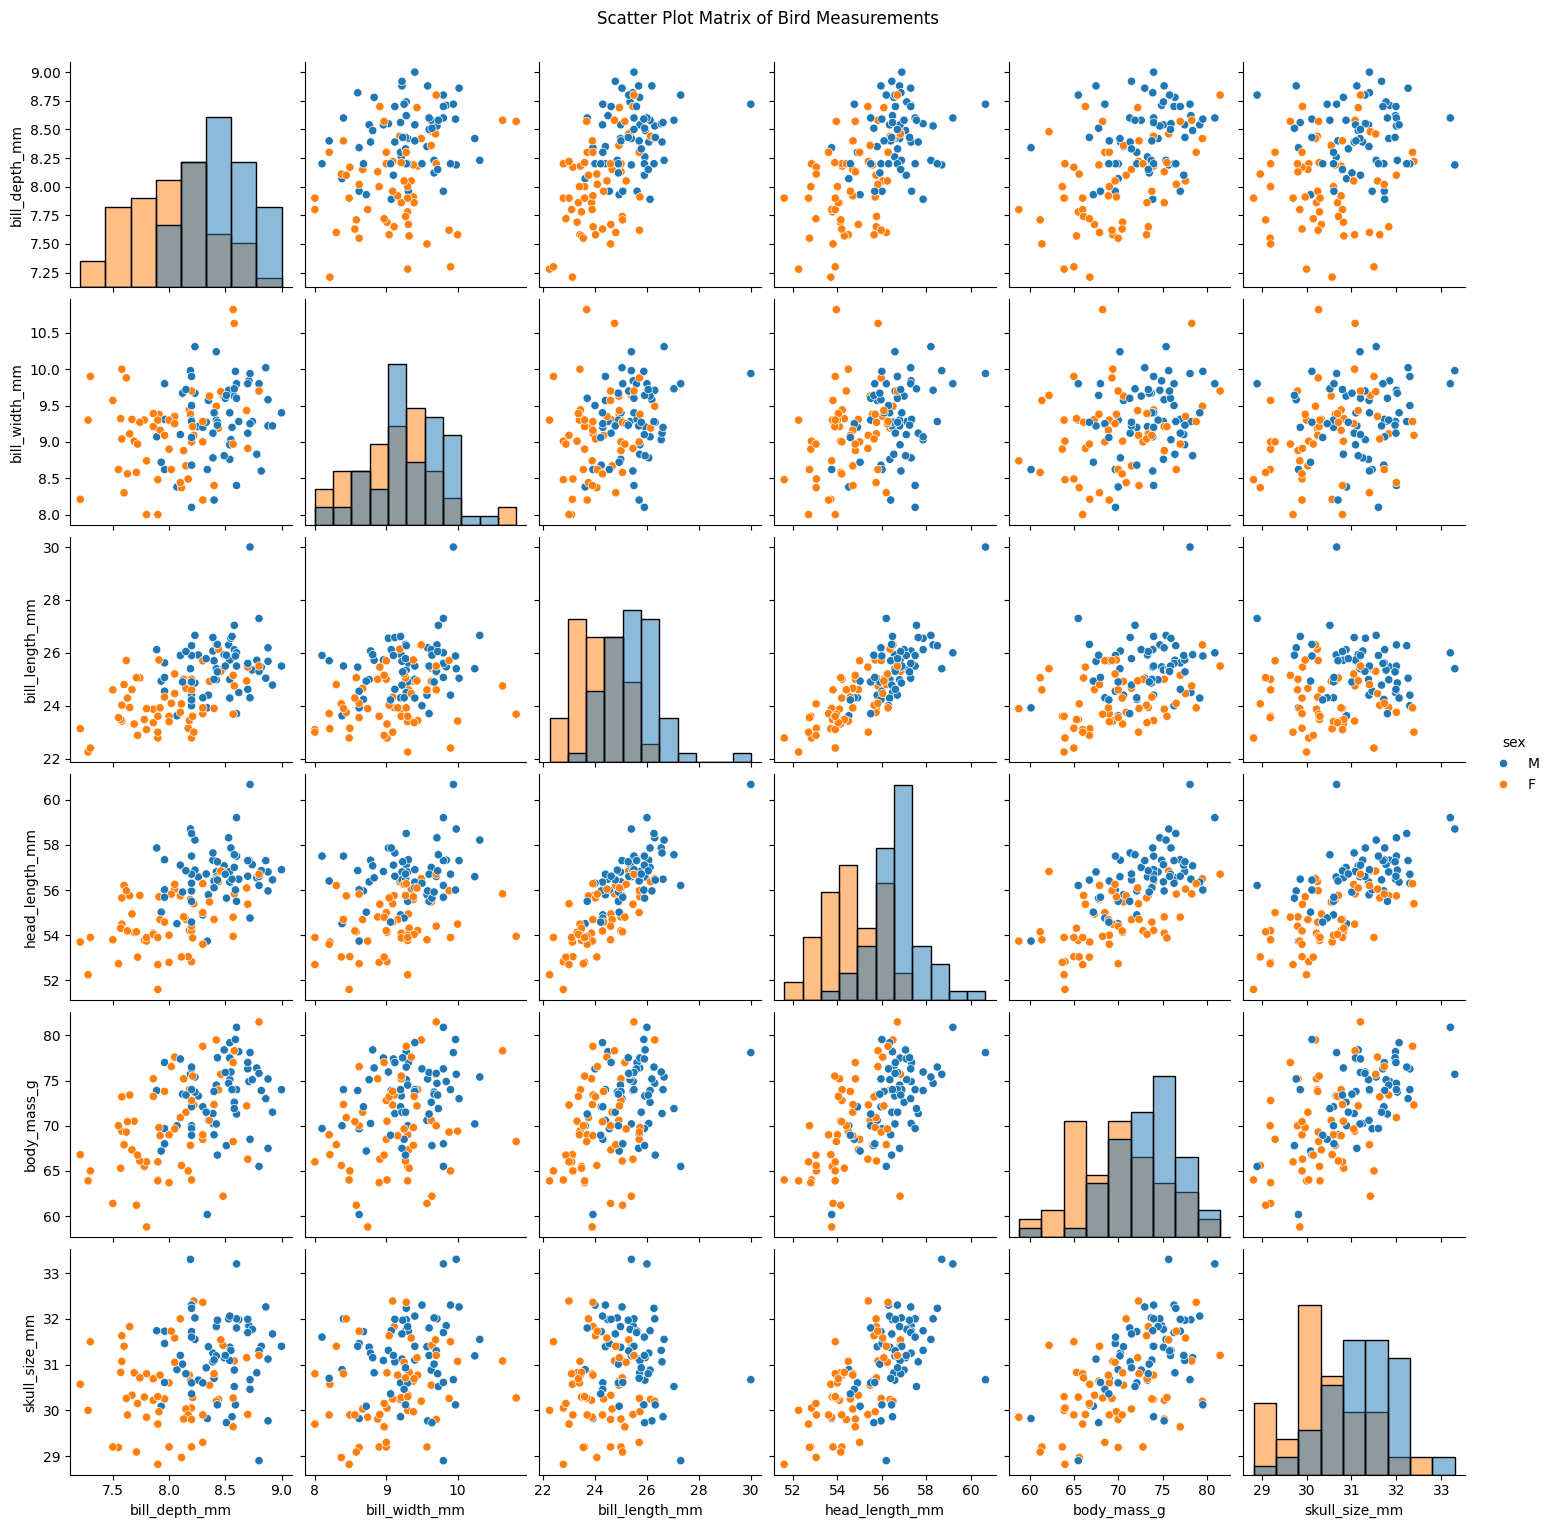

In [9]:
numeric_cols = [
    "bill_depth_mm", "bill_width_mm", "bill_length_mm",
    "head_length_mm", "body_mass_g", "skull_size_mm"
]

sns.pairplot(
    blue_jays,
    vars=numeric_cols,
    hue="sex",
    diag_kind="hist"
)
plt.suptitle("Scatter Plot Matrix of Bird Measurements", y=1.02)
plt.show()

## 7. Read the forensic glass dataset

In [10]:
forensic_glass = pd.read_csv("/kaggle/input/datasets/eimieimieimi86/glass-data/glass.csv")
forensic_glass.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type of glass
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 8. Convert and group the glass type variable

In [14]:
forensic_glass["Type of glass"] = forensic_glass["Type of glass"].astype(str)

type_map = {
    "1": "window",
    "2": "window",
    "3": "window",
    "5": "containers",
    "6": "tableware",
    "7": "headlamps"
}

forensic_glass["type"] = forensic_glass["Type of glass"].map(type_map)

forensic_glass["type"] = pd.Categorical(
    forensic_glass["type"],
    categories=["headlamps", "tableware", "containers", "window"],
    ordered=True
)

forensic_glass[["Type of glass", "type"]].head()

,Type of glass,type
0,1,window
1,1,window
2,1,window
3,1,window
4,1,window


## 9. Select only the variables used in PCA

The original R code removed columns 1, 11, and 12.

In [23]:
glass_data = forensic_glass.drop(columns=['Id', 'Type of glass', 'type'])
glass_data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


## 10. Standardize the data

In [25]:
scaler = StandardScaler()
glass_scaled = scaler.fit_transform(glass_data)


## 11. Apply PCA

In [27]:
pca = PCA()
pca_scores = pca.fit_transform(glass_scaled)

## 12. PCA loadings

## 13. PCA summary

In [31]:
explained_var = pd.DataFrame({
    "Variance": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_)
})

explained_var

,Variance,Cumulative
0,0.279018,0.279018
1,0.227786,0.506804
2,0.156094,0.662898
3,0.128651,0.791549
4,0.101556,0.893105
5,0.058626,0.951731
6,0.040995,0.992726
7,0.007095,0.999821
8,0.000179,1.000000


In [29]:
loadings = pd.DataFrame(pca.components_[:2].T,
                        index=glass_data.columns,
                        columns=['PC1', 'PC2'])

loadings

,PC1,PC2
RI,0.545177,-0.285683
Na,-0.258126,-0.270350
Mg,0.110881,0.593558
Al,-0.428709,-0.295212
Si,-0.228836,0.155099
K,-0.219344,0.153970
Ca,0.492306,-0.345380
Ba,-0.250375,-0.484702
Fe,0.185842,0.062039


## 14. PCA scores dataframe

In [33]:
pca_scores_df = pd.DataFrame(pca_scores, columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9'])
pca_scores_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1.151140,0.529488,-0.372096,-1.728901,-0.251936,0.340210,0.395600,0.197160,-0.016346
1,-0.574137,0.759788,-0.556708,-0.760232,-0.257071,-0.115960,0.024158,0.284214,0.010790
2,-0.940160,0.929836,-0.554907,-0.206254,-0.237506,0.126630,0.367518,0.095941,-0.021640
3,-0.142083,0.961677,-0.117125,-0.415724,-0.476299,0.285805,0.052497,0.002959,-0.092035
4,-0.351092,1.091249,-0.485079,-0.069102,-0.432090,0.298032,-0.158570,0.191316,-0.002315


## 15. Loading plot for PC1 and PC2 ( Optional nor required)

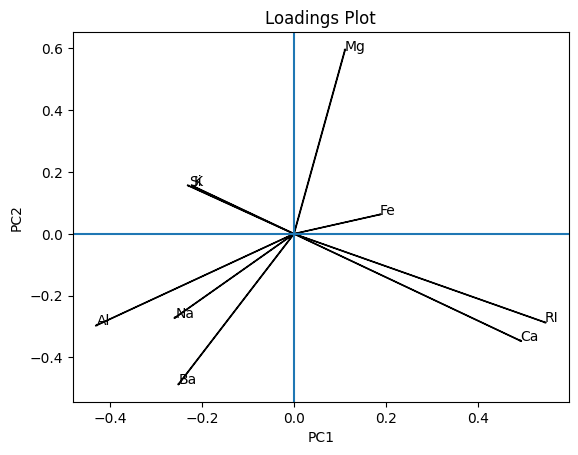

In [35]:
plt.figure()

for i in range(len(loadings)):
    x = loadings.iloc[i, 0]   # PC1
    y = loadings.iloc[i, 1]   # PC2
    
    plt.arrow(0, 0, x, y)
    plt.text(x, y, loadings.index[i])

plt.axhline(0)
plt.axvline(0)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Loadings Plot")

plt.show()

## 16. PCA scatter plot using the first two principal components

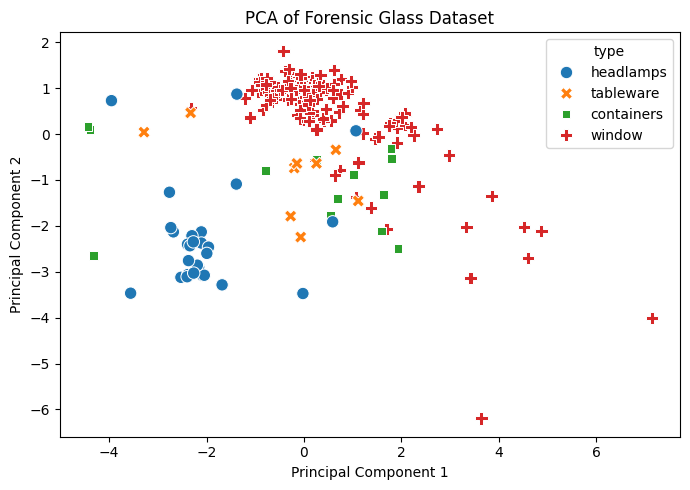

In [36]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=pca_scores_df,
    x="PC1",
    y="PC2",
    hue=forensic_glass["type"],
    style=forensic_glass["type"],
    s=80
)
plt.title("PCA of Forensic Glass Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

## 17. Correlation matrix

In [37]:
corr_matrix = glass_data.corr()
corr_matrix

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
RI,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010
Na,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346
Mg,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060
Al,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402
Si,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201
K,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719
Ca,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968
Ba,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692
Fe,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000


## 18. Correlation heatmap

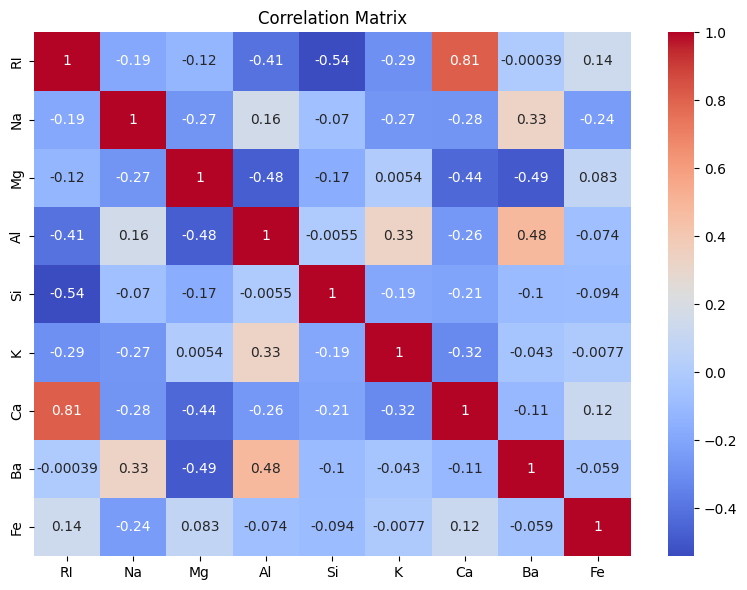

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 19. Upper triangle correlation heatmap

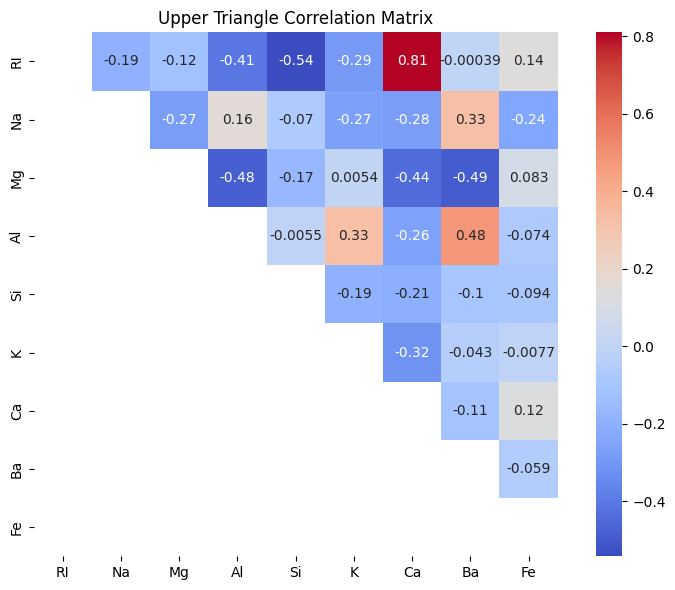

In [39]:
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    square=True
)
plt.title("Upper Triangle Correlation Matrix")
plt.tight_layout()
plt.show()